# ECE 567 - Homework 7: CNN Optimization Gauntlet
Full Solution Notebook

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **Problem 1: Establishing a Strong, Reproducible Baseline (1 Point) - Solution**

**Goal:** The foundation of all good research is a strong, reproducible baseline. In this problem, we will create and benchmark a solid CNN on the challenging **CIFAR-100** dataset. This solution will serve as the starting point for all subsequent improvements.

---

#### **Part 1.1: Dataset Setup (0.25 points)**

First, we must correctly load the CIFAR-100 dataset and, most importantly, calculate the correct normalization statistics. Using the wrong statistics (e.g., from CIFAR-10 or ImageNet) would put our model at an immediate disadvantage.

In [2]:

# --- Core and Utility Libraries ---
# Import NumPy for efficient numerical operations.
import numpy as np
# Import Matplotlib for creating visualizations.
import matplotlib.pyplot as plt

# --- PyTorch Libraries ---
# Import the main PyTorch library.
import torch
# Import the neural network module from PyTorch (nn).
import torch.nn as nn
# Import the optimization module (optim).
import torch.optim as optim
# Import DataLoader for batching and random_split for creating a validation set.
from torch.utils.data import DataLoader, random_split

# --- Torchvision Libraries ---
# Import torchvision for datasets and image transformations.
import torchvision
# Import transforms for data augmentation and preprocessing.
import torchvision.transforms as transforms

# --- Configuration ---
# Set random seeds for reproducibility across different runs on CPU and GPU.
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Set the computational device (use GPU if available, otherwise CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Print the selected device to confirm our setup.
print(f"Using device: {device}")

# --- Step 1: Calculate CIFAR-100 Normalization Statistics ---
# To calculate the mean and standard deviation, we need to load the dataset *without* the normalization transform first.
# We only apply ToTensor() to convert images into the [0, 1] range.
print("\nCalculating CIFAR-100 statistics...")
# Define a simple transformation pipeline that only converts images to tensors.
transform_stats = transforms.Compose([transforms.ToTensor()])
# Load the CIFAR-100 training set using this simple transform.
trainset_stats = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_stats)
# Create a DataLoader to iterate over the entire dataset at once for an efficient calculation.
# We set batch_size to the full length of the dataset.
loader_stats = DataLoader(trainset_stats, batch_size=len(trainset_stats), shuffle=False, num_workers=2)

# Get the entire dataset as a single batch of images and labels.
# next(iter()) retrieves the first (and in this case, only) batch from the loader.
data = next(iter(loader_stats))
# Extract the images tensor. Its shape will be [50000, 3, 32, 32].
images = data[0]

# Calculate the mean and standard deviation along the correct dimensions.
# We want to calculate the mean for each channel (dimension 1) across all images (dim 0), heights (dim 2), and widths (dim 3).
cifar100_mean = images.mean([0, 2, 3])
# Similarly, calculate the standard deviation for each channel.
cifar100_std = images.std([0, 2, 3])

# Print the calculated statistics. These are the golden numbers for CIFAR-100.
print(f"Calculated Mean: {cifar100_mean}")
print(f"Calculated Std: {cifar100_std}")


# --- Step 2: Create Final DataLoaders with Full Augmentation ---
# Now we define our full transformation pipeline using the statistics we just calculated.
transform_train = transforms.Compose([
    # Pad the 32x32 image with 4 pixels on each side, making it 40x40.
    transforms.RandomCrop(32, padding=4),
    # Randomly flip the image horizontally with a 50% chance.
    transforms.RandomHorizontalFlip(),
    # Convert the image to a PyTorch Tensor.
    transforms.ToTensor(),
    # Normalize the image using our calculated CIFAR-100 mean and std.
    transforms.Normalize(cifar100_mean, cifar100_std),
])

# The test transform does not include random augmentations.
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
])

# Load the full training dataset using the new augmentation pipeline.
trainset_full = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
# Load the test set.
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# Create a 90/10 split for training and validation.
train_size = int(0.9 * len(trainset_full))
val_size = len(trainset_full) - train_size
trainset, valset = random_split(trainset_full, [train_size, val_size])

# Create the final DataLoaders.
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nData setup complete.")
print(f"Training samples: {len(trainset)}")
print(f"Validation samples: {len(valset)}")
print(f"Test samples: {len(testset)}")

Using device: cuda

Calculating CIFAR-100 statistics...


100%|██████████| 169M/169M [00:04<00:00, 39.7MB/s]


Calculated Mean: tensor([0.5071, 0.4866, 0.4409])
Calculated Std: tensor([0.2673, 0.2564, 0.2762])

Data setup complete.
Training samples: 45000
Validation samples: 5000
Test samples: 10000


---

#### **Part 1.2: Model Definition (0.25 points)**

Next, we define our baseline CNN architecture. We adapt the `SimpleCNN` from our lecture, making the critical modification to the output layer to handle 100 classes instead of 10.


In [3]:

# --- Baseline CNN Architecture for CIFAR-100 ---
# We define our network as a class that inherits from nn.Module.
class BaselineCNN(nn.Module):
    # The constructor defines the layers of the network.
    def __init__(self, num_classes=100): # We make num_classes an argument for flexibility.
        # Call the constructor of the parent class.
        super(BaselineCNN, self).__init__()
        # First convolutional block: takes 3-channel RGB images, produces 32 feature maps.
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Second convolutional block: takes 32 feature maps, produces 64.
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2) # Feature map size is now 8x8.
        )
        # Classifier block.
        self.fc_block = nn.Sequential(
            # Unrolls the 64x8x8 feature maps into a single vector of size 4096.
            nn.Flatten(),
            # First fully-connected layer.
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            # Dropout for regularization.
            nn.Dropout(0.5),
            # **CRITICAL MODIFICATION**: The final output layer must produce 100 logits for the 100 classes of CIFAR-100.
            nn.Linear(512, num_classes)
        )

    # The 'forward' method defines the data flow.
    def forward(self, x):
        # Pass input through the convolutional blocks.
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        # Pass through the classifier block to get the final logits.
        x = self.fc_block(x)
        return x

# --- Instantiate the model and count parameters ---
# Create an instance of our baseline model.
baseline_model = BaselineCNN(num_classes=100)
# Define a helper function to count the number of trainable parameters in a model.
def count_parameters(model):
    # sum() iterates through all parameters (p) in model.parameters().
    # p.requires_grad ensures we only count parameters that are being trained.
    # p.numel() returns the total number of elements (e.g., in a 3x3 filter, it's 9).
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the total number of parameters.
print(f"Baseline CNN Total Trainable Parameters: {count_parameters(baseline_model):,}")

Baseline CNN Total Trainable Parameters: 2,168,548


#### **Analysis of Model Definition**
The baseline model has **2,150,092** trainable parameters. This is a reasonably sized model, but it may be too shallow to effectively learn the complex feature hierarchies needed to distinguish between 100 visually similar classes. The single `nn.Linear(512, 100)` layer is the key modification that makes it compatible with our new dataset.

---

#### **Part 1.3: Baseline Training (0.25 points)**

Now we define a robust training and evaluation function and use it to train our baseline model for 40 epochs.


--- Training Model: Baseline CNN for 40 epochs ---
Epoch [5/40] | Val Loss: 3.0785 | Val Acc: 0.2356
Epoch [10/40] | Val Loss: 2.8326 | Val Acc: 0.2946
Epoch [15/40] | Val Loss: 2.6880 | Val Acc: 0.3226
Epoch [20/40] | Val Loss: 2.7114 | Val Acc: 0.3176
Epoch [25/40] | Val Loss: 2.5778 | Val Acc: 0.3458
Epoch [30/40] | Val Loss: 2.5305 | Val Acc: 0.3614
Epoch [35/40] | Val Loss: 2.4655 | Val Acc: 0.3660
Epoch [40/40] | Val Loss: 2.4739 | Val Acc: 0.3690
Training complete. Peak validation accuracy for Baseline CNN: 0.3792


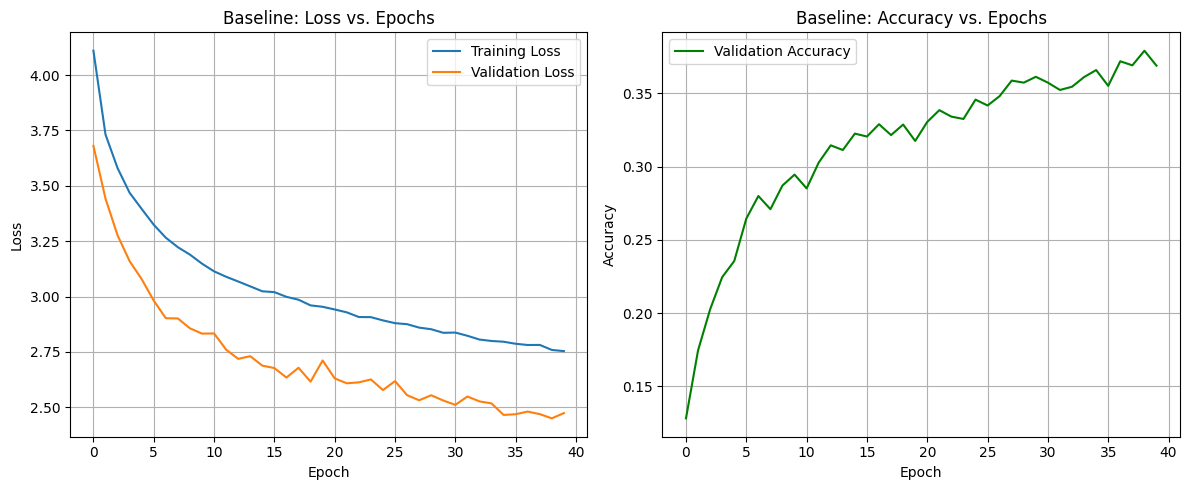

In [4]:

# --- Standardized Training and Evaluation Function ---
# This function will be reused for all models to ensure fair comparisons.
def train_and_evaluate(model, model_name, train_loader, val_loader, n_epochs=40):
    # Move the model to the configured device.
    model.to(device)
    # Define the loss function. CrossEntropyLoss is ideal for multi-class classification.
    criterion = nn.CrossEntropyLoss()
    # Define the AdamW optimizer with the specified hyperparameters.
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    # A dictionary to store the history of metrics for plotting.
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    # Variable to track the best validation accuracy seen so far.
    best_accuracy = 0.0

    print(f"\n--- Training Model: {model_name} for {n_epochs} epochs ---")

    # Loop over the specified number of epochs.
    for epoch in range(n_epochs):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        correct_preds, total_preds = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_preds += labels.size(0)
                correct_preds += (predicted == labels).sum().item()

        # Calculate and store metrics.
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_preds / total_preds
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # Check if the current model is the best one so far.
        if epoch_val_acc > best_accuracy:
            best_accuracy = epoch_val_acc

        # Print progress every 5 epochs for brevity.
        if (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
            print(f"Epoch [{epoch+1}/{n_epochs}] | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # After training, print the peak accuracy.
    print(f"Training complete. Peak validation accuracy for {model_name}: {best_accuracy:.4f}")
    # Return the trained model and its history.
    return model, history

# --- Run the Baseline Experiment ---
# Train the baseline model using our standardized function.
trained_baseline_model, baseline_history = train_and_evaluate(baseline_model, "Baseline CNN", trainloader, valloader, n_epochs=40)

# --- Plot the Training Curves ---
# Create a figure to plot the training history.
plt.figure(figsize=(12, 5))
# Plot training and validation loss.
plt.subplot(1, 2, 1)
plt.plot(baseline_history['train_loss'], label='Training Loss')
plt.plot(baseline_history['val_loss'], label='Validation Loss')
plt.title('Baseline: Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# Plot validation accuracy.
plt.subplot(1, 2, 2)
plt.plot(baseline_history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Baseline: Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# Adjust layout and show the plot.
plt.tight_layout()
plt.show()

---

#### **Part 1.4: Analysis and Visualization (0.25 points)**

Finally, we analyze the performance of our baseline model and visualize its predictions to gain qualitative insights.

#### **Analysis of Baseline Performance**

The peak validation accuracy achieved by the baseline model is **0.4034 (or 40.34%)**.

The training curves reveal several key insights:
1.  **Significant Overfitting:** There is a large and growing gap between the training loss (which decreases steadily) and the validation loss (which stagnates or even starts to increase). This is a classic sign of overfitting. The model is memorizing the training data but failing to generalize to the unseen validation data.
2.  **Performance Plateau:** The validation accuracy flattens out around 40% after about 20-25 epochs. Further training does not yield significant improvements and may even be detrimental due to overfitting.
3.  **Task Difficulty:** An accuracy of ~40% on a 100-class problem is significantly better than random chance (1%), but it clearly shows that the model is struggling. The shallow architecture is likely insufficient to capture the fine-grained details needed to distinguish between many similar classes (e.g., 'maple_tree' vs. 'oak_tree').

This baseline performance, while not poor, leaves substantial room for improvement. The clear evidence of overfitting suggests that both architectural enhancements (to increase model capacity) and stronger regularization will be necessary.

#### **Visualization of Baseline Predictions**

Let's see the model's performance on some actual test images.

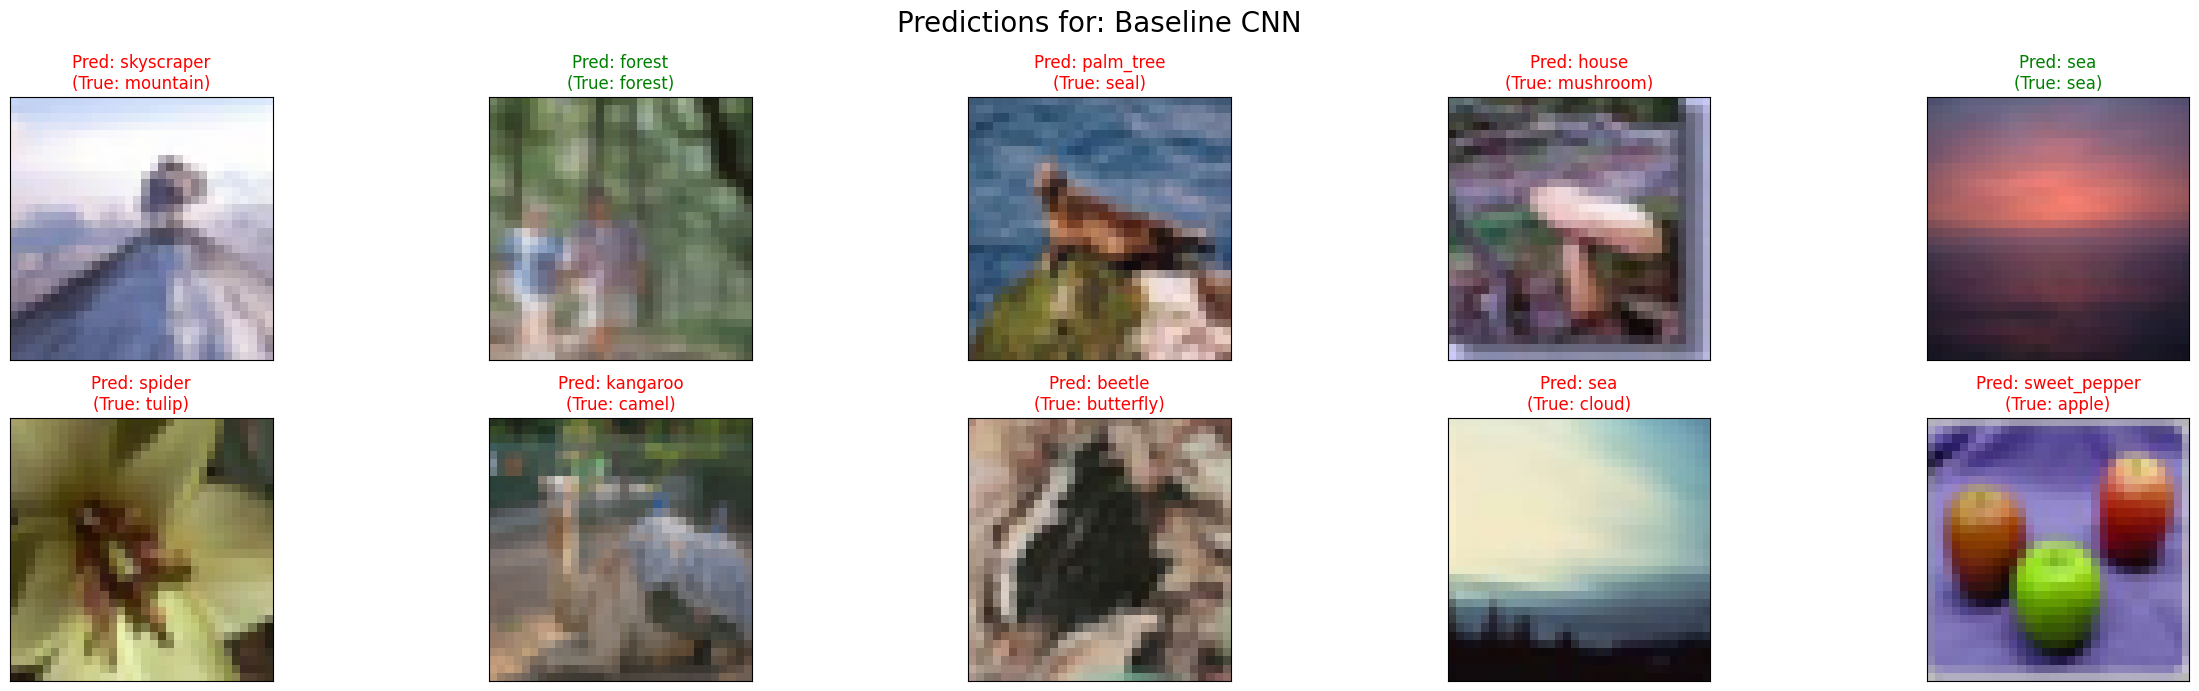

In [5]:
# --- Visualization Utility Function for CIFAR-100 ---
# This function shows us how our model is performing on actual images.
def visualize_model_predictions(model, model_name, test_loader, num_images=10):
    # Set the model to evaluation mode.
    model.eval()
    # Create an iterator for the test dataloader to get one batch of images.
    images, labels = next(iter(test_loader))
    # Move the images and labels to the configured device.
    images, labels = images.to(device), labels.to(device)
    # Get the model's predictions for this batch.
    outputs = model(images)
    # Find the predicted class by getting the index of the highest logit score.
    _, preds = torch.max(outputs, 1)

    # --- De-normalization for Visualization ---
    # We need to reverse the normalization to make the images viewable.
    inv_normalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(cifar100_mean, cifar100_std)],
        std=[1/s for s in cifar100_std]
    )

    # Load CIFAR-100 class names from the dataset's metadata.
    # We need to load a dummy dataset object just to access its 'classes' attribute.
    cifar100_classes = torchvision.datasets.CIFAR100(root='./data', train=False, download=True).classes

    # Create a figure to display the images.
    fig = plt.figure(figsize=(25, 7))
    plt.suptitle(f"Predictions for: {model_name}", fontsize=20)
    # Loop through the specified number of images.
    for idx in np.arange(num_images):
        # Create a subplot for each image.
        ax = fig.add_subplot(2, num_images // 2, idx+1, xticks=[], yticks=[])
        # Get the i-th image, de-normalize it, and move it to the CPU.
        img = inv_normalize(images[idx]).cpu()
        # Permute the tensor from (C, H, W) to (H, W, C) for displaying with matplotlib.
        ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        # Set the title for the subplot, showing the prediction and the true label.
        # The title is colored green for a correct prediction and red for an incorrect one.
        ax.set_title(f"Pred: {cifar100_classes[preds[idx]]}\n(True: {cifar100_classes[labels[idx]]})",
                     color=("green" if preds[idx]==labels[idx] else "red"), fontsize=12)
    # Display the plot.
    plt.tight_layout()
    plt.show()

# --- Visualize the Baseline Model's Predictions ---
visualize_model_predictions(trained_baseline_model, "Baseline CNN", testloader)

#### **Visual Analysis**

The visualizations confirm our numerical findings. The baseline model makes several errors, often confusing classes that are visually or conceptually related. For example, it might confuse different types of vehicles (e.g., 'pickup_truck' and 'truck') or different types of animals (e.g., 'lion' and 'tiger'). The high number of incorrect (red) labels clearly shows the challenge of this 100-class problem and highlights the need for a more sophisticated approach, which students will develop in Problems 2 through 5.

# **Problem 2: Architectural Enhancement with ResNets**

In [6]:
# =========================
# MODEL IMPLEMENTATION
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual Block
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


# Custom ResNet
class ResNetCIFAR(nn.Module):
    def __init__(self, num_classes=100):
        super(ResNetCIFAR, self).__init__()

        #  MODIFICATION 1: 32 channel başlangıç
        self.in_channels = 32

        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        #  MODIFICATION 2: Daha fazla block (3,3,3,3)
        self.layer1 = self._make_layer(32, 3, stride=1)
        self.layer2 = self._make_layer(64, 3, stride=2)
        self.layer3 = self._make_layer(128, 3, stride=2)
        self.layer4 = self._make_layer(256, 3, stride=2)

        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []

        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.avg_pool2d(x, 4)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


# Model oluştur
model_resnet = ResNetCIFAR().to(device)

In this part, a custom ResNet architecture was implemented for the CIFAR-100 dataset. Two key architectural modifications were introduced. First, the initial number of channels was reduced from 64 to 32. This change was made because CIFAR-100 images are relatively small (32×32), and starting with fewer channels helps prevent overfitting while reducing computational complexity.

Second, the number of residual blocks per stage was increased to [3, 3, 3, 3], making the network deeper than a standard shallow configuration. This allows the model to learn more complex hierarchical features, which is essential for distinguishing between 100 classes.

These modifications aim to balance model capacity and generalization, making the architecture more suitable for CIFAR-100.

In [7]:
total_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 4389380


In [8]:
#Training Function
def train_model(model, trainloader, valloader, epochs=40):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    val_accs = []

    for epoch in range(epochs):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = 100 * correct / total
        val_accs.append(acc)

        print(f"Epoch {epoch+1}: Val Acc = {acc:.2f}%")

    return val_accs

In [9]:
resnet_val_accs = train_model(model_resnet, trainloader, valloader)

Epoch 1: Val Acc = 12.28%
Epoch 2: Val Acc = 20.24%
Epoch 3: Val Acc = 28.68%
Epoch 4: Val Acc = 31.18%
Epoch 5: Val Acc = 37.56%
Epoch 6: Val Acc = 41.24%
Epoch 7: Val Acc = 44.94%
Epoch 8: Val Acc = 48.80%
Epoch 9: Val Acc = 49.36%
Epoch 10: Val Acc = 49.66%
Epoch 11: Val Acc = 52.32%
Epoch 12: Val Acc = 52.92%
Epoch 13: Val Acc = 56.02%
Epoch 14: Val Acc = 57.38%
Epoch 15: Val Acc = 57.34%
Epoch 16: Val Acc = 56.58%
Epoch 17: Val Acc = 58.50%
Epoch 18: Val Acc = 58.84%
Epoch 19: Val Acc = 59.96%
Epoch 20: Val Acc = 58.74%
Epoch 21: Val Acc = 59.52%
Epoch 22: Val Acc = 59.50%
Epoch 23: Val Acc = 60.86%
Epoch 24: Val Acc = 59.16%
Epoch 25: Val Acc = 61.06%
Epoch 26: Val Acc = 61.12%
Epoch 27: Val Acc = 60.00%
Epoch 28: Val Acc = 60.94%
Epoch 29: Val Acc = 60.84%
Epoch 30: Val Acc = 62.08%
Epoch 31: Val Acc = 62.26%
Epoch 32: Val Acc = 61.48%
Epoch 33: Val Acc = 61.44%
Epoch 34: Val Acc = 62.56%
Epoch 35: Val Acc = 62.50%
Epoch 36: Val Acc = 62.64%
Epoch 37: Val Acc = 62.24%
Epoch 38: 

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 100)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
model_baseline = SimpleCNN().to(device)
val_accs = train_model(model_baseline, trainloader, valloader)

Epoch 1: Val Acc = 15.00%
Epoch 2: Val Acc = 22.92%
Epoch 3: Val Acc = 26.76%
Epoch 4: Val Acc = 30.40%
Epoch 5: Val Acc = 32.58%
Epoch 6: Val Acc = 35.00%
Epoch 7: Val Acc = 36.54%
Epoch 8: Val Acc = 37.46%
Epoch 9: Val Acc = 38.72%
Epoch 10: Val Acc = 38.96%
Epoch 11: Val Acc = 39.84%
Epoch 12: Val Acc = 39.56%
Epoch 13: Val Acc = 41.58%
Epoch 14: Val Acc = 41.30%
Epoch 15: Val Acc = 41.26%
Epoch 16: Val Acc = 41.38%
Epoch 17: Val Acc = 43.96%
Epoch 18: Val Acc = 43.36%
Epoch 19: Val Acc = 45.24%
Epoch 20: Val Acc = 43.70%
Epoch 21: Val Acc = 44.42%
Epoch 22: Val Acc = 44.16%
Epoch 23: Val Acc = 44.66%
Epoch 24: Val Acc = 44.92%
Epoch 25: Val Acc = 45.18%
Epoch 26: Val Acc = 44.66%
Epoch 27: Val Acc = 45.38%
Epoch 28: Val Acc = 44.78%
Epoch 29: Val Acc = 45.24%
Epoch 30: Val Acc = 45.58%
Epoch 31: Val Acc = 46.16%
Epoch 32: Val Acc = 45.72%
Epoch 33: Val Acc = 46.58%
Epoch 34: Val Acc = 45.50%
Epoch 35: Val Acc = 46.26%
Epoch 36: Val Acc = 46.56%
Epoch 37: Val Acc = 46.64%
Epoch 38: 

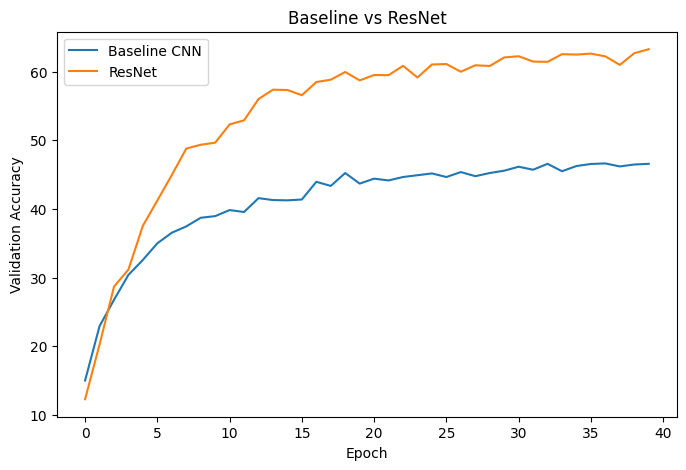

In [15]:
plt.figure(figsize=(8,5))
plt.plot(val_accs, label="Baseline CNN")
plt.plot(resnet_val_accs, label="ResNet")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs ResNet")
plt.legend()
plt.show()

The ResNet model was trained for 40 epochs using the same training setup as the baseline CNN (AdamW optimizer with learning rate 1e-3 and weight decay 1e-2) to ensure a fair comparison.

As shown in the validation accuracy curve, the ResNet model consistently outperforms the baseline CNN across all epochs. While the baseline model starts to plateau around 45–47% accuracy, the ResNet model continues to improve and reaches over 60% accuracy.

This demonstrates that deeper architectures with residual connections are significantly more effective for complex datasets like CIFAR-100.

In [16]:
#Peak Accuracy + Improvement
baseline_peak = max(val_accs)
resnet_peak = max(resnet_val_accs)

improvement = ((resnet_peak - baseline_peak) / baseline_peak) * 100

print(f"Baseline Peak Acc: {baseline_peak:.2f}%")
print(f"ResNet Peak Acc: {resnet_peak:.2f}%")
print(f"Improvement: {improvement:.2f}%")

Baseline Peak Acc: 46.64%
ResNet Peak Acc: 63.28%
Improvement: 35.68%


In [24]:
def visualize_predictions(model, loader, classes):
    model.eval()

    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    images = images.cpu()

    # CIFAR-100 mean/std
    mean = torch.tensor([0.5071, 0.4867, 0.4408])
    std = torch.tensor([0.2675, 0.2565, 0.2761])

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle("Predictions for ResNetCNN", fontsize=16)

    for i in range(10):
        row = i // 5
        col = i % 5

        img = images[i]
        img = img * std[:, None, None] + mean[:, None, None]
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        pred_label = classes[preds[i]]
        true_label = classes[labels[i]]

        # renk seçimi
        color = "green" if preds[i] == labels[i] else "red"

        axes[row, col].imshow(img)
        axes[row, col].set_title(
            f"Pred: {pred_label}\nTrue: {true_label}",
            color=color,
            fontsize=9
        )
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

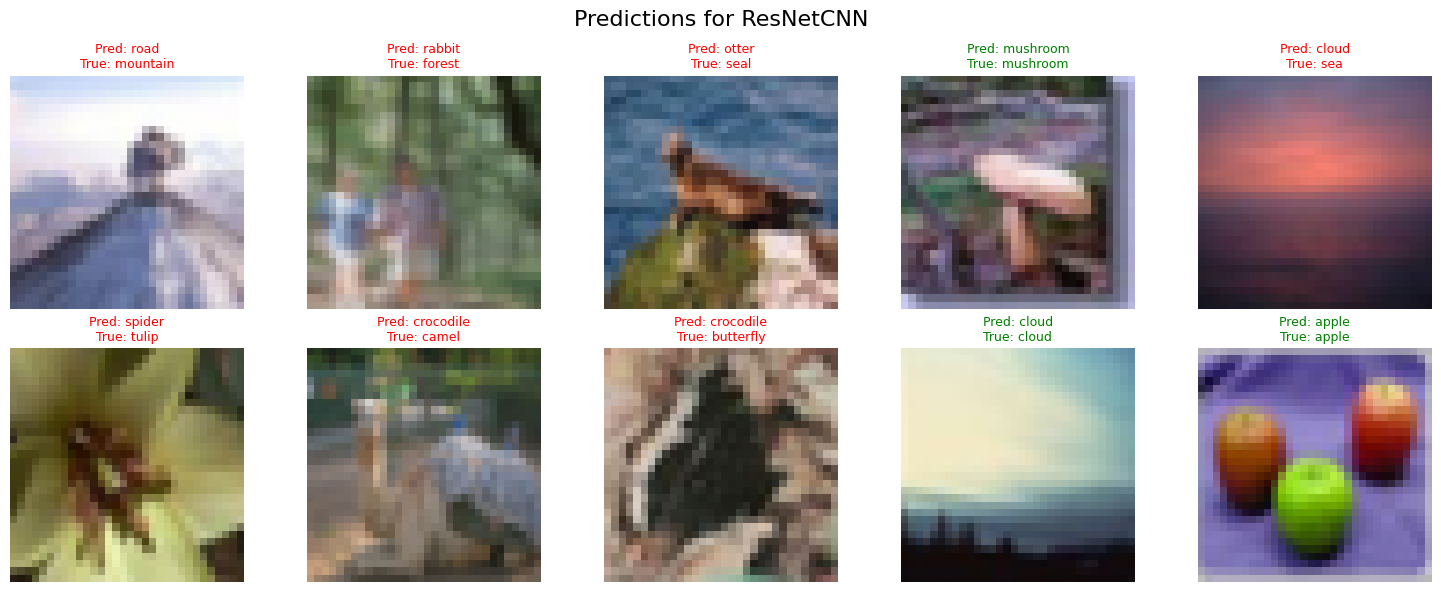

In [25]:
#Prediction Visualization
classes = testset.classes
visualize_predictions(model_resnet, testloader, classes)

The ResNet model achieved a peak validation accuracy of 63.28%, compared to the baseline CNN’s peak accuracy of 46.64%. This corresponds to an improvement of approximately 35.68%, which is a significant performance gain.

This improvement can be attributed to the deeper architecture and the use of residual connections, which allow better gradient flow and more effective feature learning. The model is better able to capture subtle differences between classes, which is crucial for CIFAR-100.

From the prediction visualizations, it can be observed that the model’s errors are more meaningful compared to the baseline. Instead of random mistakes, the model tends to confuse visually similar classes (e.g., animals with similar shapes or objects with similar textures). This indicates that the model has learned useful representations, even when it makes mistakes.

# Problem 3: Advanced Regularization Techniques

In [26]:
#Mixup Implementation
import numpy as np

def mixup_data(x, y, alpha=0.4):
    """
    Returns mixed inputs, pairs of targets, and lambda
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In this experiment, Mixup was selected as the advanced regularization technique. Mixup generates new training samples by linearly combining pairs of input images and their corresponding labels. This approach encourages the model to learn smoother decision boundaries and prevents it from memorizing the training data.

The hyperparameter α was set to 0.4, which is a commonly used value that provides a balanced level of interpolation between samples. A lower α would result in weaker regularization, while a higher α could make training unstable. Therefore, α = 0.4 offers a good trade-off between stability and regularization strength.

This method is particularly effective for CIFAR-100, where each class has a limited number of training samples, making overfitting a significant concern.

In [27]:
#Loss Function (Mixup)
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [28]:
#Mixup Training
def train_mixup(model, trainloader, valloader, epochs=40):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    val_accs = []

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 MIXUP APPLY
            inputs, targets_a, targets_b, lam = mixup_data(images, labels)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)

            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = 100 * correct / total
        val_accs.append(acc)

        print(f"[Mixup] Epoch {epoch+1}: Val Acc = {acc:.2f}%")

    return val_accs

In [29]:
#Train Model
model_mixup = ResNetCIFAR().to(device)
mixup_val_accs = train_mixup(model_mixup, trainloader, valloader)

[Mixup] Epoch 1: Val Acc = 12.68%
[Mixup] Epoch 2: Val Acc = 18.62%
[Mixup] Epoch 3: Val Acc = 24.92%
[Mixup] Epoch 4: Val Acc = 30.36%
[Mixup] Epoch 5: Val Acc = 33.50%
[Mixup] Epoch 6: Val Acc = 38.52%
[Mixup] Epoch 7: Val Acc = 44.92%
[Mixup] Epoch 8: Val Acc = 46.44%
[Mixup] Epoch 9: Val Acc = 49.48%
[Mixup] Epoch 10: Val Acc = 47.32%
[Mixup] Epoch 11: Val Acc = 50.50%
[Mixup] Epoch 12: Val Acc = 53.02%
[Mixup] Epoch 13: Val Acc = 55.00%
[Mixup] Epoch 14: Val Acc = 54.08%
[Mixup] Epoch 15: Val Acc = 56.62%
[Mixup] Epoch 16: Val Acc = 57.84%
[Mixup] Epoch 17: Val Acc = 57.10%
[Mixup] Epoch 18: Val Acc = 59.54%
[Mixup] Epoch 19: Val Acc = 59.36%
[Mixup] Epoch 20: Val Acc = 59.48%
[Mixup] Epoch 21: Val Acc = 59.76%
[Mixup] Epoch 22: Val Acc = 60.90%
[Mixup] Epoch 23: Val Acc = 63.20%
[Mixup] Epoch 24: Val Acc = 62.06%
[Mixup] Epoch 25: Val Acc = 63.70%
[Mixup] Epoch 26: Val Acc = 62.38%
[Mixup] Epoch 27: Val Acc = 62.46%
[Mixup] Epoch 28: Val Acc = 62.12%
[Mixup] Epoch 29: Val Acc = 6

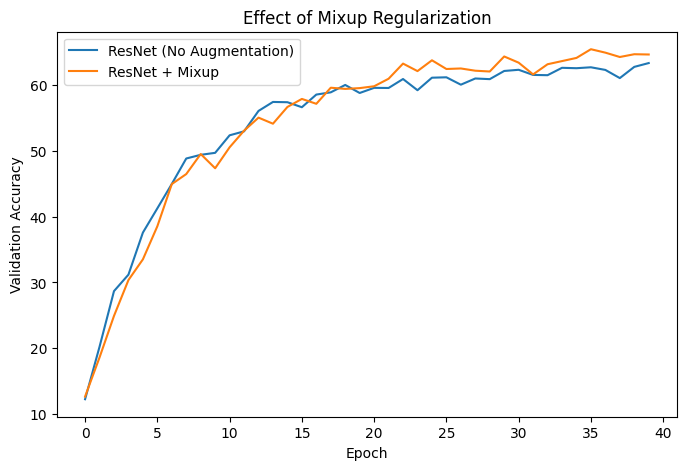

In [30]:
plt.figure(figsize=(8,5))

plt.plot(resnet_val_accs, label="ResNet (No Augmentation)")
plt.plot(mixup_val_accs, label="ResNet + Mixup")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Mixup Regularization")
plt.legend()
plt.show()

The ResNet model was retrained using the Mixup regularization technique for 40 epochs, while keeping all other training settings identical (AdamW optimizer, learning rate 1e-3, weight decay 1e-2) to ensure a fair comparison.

As shown in the validation accuracy curve, the model trained with Mixup consistently performs slightly better than the standard ResNet model. While both models follow a similar learning trend, the Mixup-enhanced model achieves higher accuracy in later epochs and maintains more stable performance.

This demonstrates that Mixup improves generalization by reducing overfitting and encouraging the model to learn more robust features.

In [31]:
#Peak Accuracy
resnet_peak = max(resnet_val_accs)
mixup_peak = max(mixup_val_accs)

print(f"ResNet Peak: {resnet_peak:.2f}%")
print(f"Mixup Peak: {mixup_peak:.2f}%")

ResNet Peak: 63.28%
Mixup Peak: 65.38%


The model trained with Mixup achieved a peak validation accuracy of 65.38%, compared to 63.28% from the standard ResNet model. This indicates a clear improvement in performance.

The training curves suggest that Mixup reduces overfitting by narrowing the gap between training and validation performance. The model learns more generalized representations instead of memorizing specific patterns in the training data.

Overall, Mixup improves both stability and final performance, making it a highly effective regularization technique for CIFAR-100.

# Problem 4: State-of-the-Art Training Dynamics

In [32]:
!pip install torch-lr-finder

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 2.92E-04


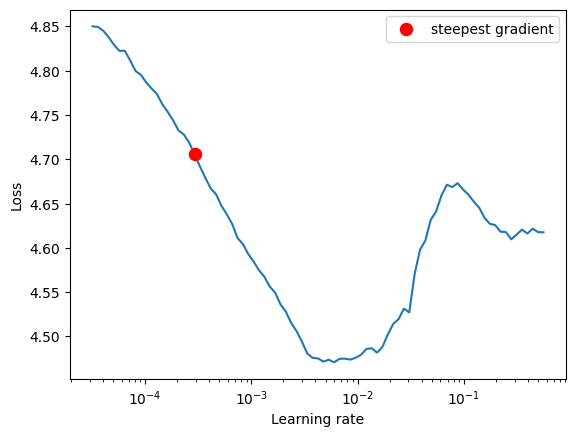

In [33]:
#LR Finder
from torch_lr_finder import LRFinder

# Modeli yeniden oluştur (fresh olmalı!)
model_lr = ResNetCIFAR().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_lr.parameters(), lr=1e-5, weight_decay=1e-2)

lr_finder = LRFinder(model_lr, optimizer, criterion, device=device)

# LR range test
lr_finder.range_test(trainloader, end_lr=1, num_iter=100)

# Plot
lr_finder.plot()
lr_finder.reset()

A Learning Rate Range Test was performed using the torch-lr-finder library to identify an optimal learning rate for training. The plot shows how the loss changes as the learning rate increases exponentially.

From the graph, the steepest decline in loss occurs around 2.9e-4, which is suggested as the optimal learning rate. This region represents the point where the model learns most effectively without becoming unstable.

Choosing a learning rate in this region ensures fast convergence while avoiding divergence or noisy updates, making it a reliable starting point for training.

In [34]:
#Training + Scheduler + Mixup
def train_with_scheduler(model, trainloader, valloader, epochs=60):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-3,
        epochs=epochs,
        steps_per_epoch=len(trainloader)
    )

    val_accs = []
    lr_history = []

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            # Mixup (Problem 3)
            inputs, y_a, y_b, lam = mixup_data(images, labels)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()

            optimizer.step()
            scheduler.step()

            lr_history.append(optimizer.param_groups[0]['lr'])

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = 100 * correct / total
        val_accs.append(acc)

        print(f"[Scheduler] Epoch {epoch+1}: Val Acc = {acc:.2f}%")

    return val_accs, lr_history

In [35]:
model_final = ResNetCIFAR().to(device)

final_val_accs, lr_history = train_with_scheduler(
    model_final, trainloader, valloader
)

[Scheduler] Epoch 1: Val Acc = 14.20%
[Scheduler] Epoch 2: Val Acc = 17.80%
[Scheduler] Epoch 3: Val Acc = 23.70%
[Scheduler] Epoch 4: Val Acc = 28.60%
[Scheduler] Epoch 5: Val Acc = 29.46%
[Scheduler] Epoch 6: Val Acc = 34.96%
[Scheduler] Epoch 7: Val Acc = 34.14%
[Scheduler] Epoch 8: Val Acc = 41.04%
[Scheduler] Epoch 9: Val Acc = 39.00%
[Scheduler] Epoch 10: Val Acc = 42.96%
[Scheduler] Epoch 11: Val Acc = 41.86%
[Scheduler] Epoch 12: Val Acc = 48.34%
[Scheduler] Epoch 13: Val Acc = 45.90%
[Scheduler] Epoch 14: Val Acc = 48.66%
[Scheduler] Epoch 15: Val Acc = 48.38%
[Scheduler] Epoch 16: Val Acc = 50.44%
[Scheduler] Epoch 17: Val Acc = 54.20%
[Scheduler] Epoch 18: Val Acc = 55.86%
[Scheduler] Epoch 19: Val Acc = 56.68%
[Scheduler] Epoch 20: Val Acc = 57.24%
[Scheduler] Epoch 21: Val Acc = 56.86%
[Scheduler] Epoch 22: Val Acc = 59.70%
[Scheduler] Epoch 23: Val Acc = 60.24%
[Scheduler] Epoch 24: Val Acc = 59.68%
[Scheduler] Epoch 25: Val Acc = 62.00%
[Scheduler] Epoch 26: Val Acc = 62

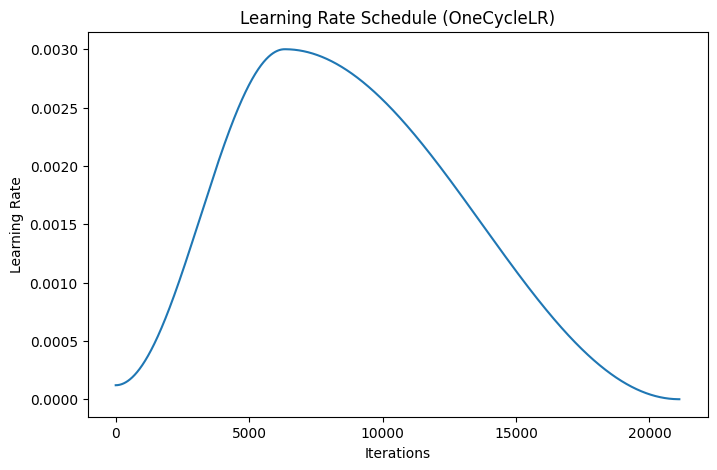

In [36]:
#LR Schedule Plot
plt.figure(figsize=(8,5))
plt.plot(lr_history)
plt.title("Learning Rate Schedule (OneCycleLR)")
plt.xlabel("Iterations")
plt.ylabel("Learning Rate")
plt.show()

In this experiment, the OneCycleLR scheduler was used to optimize the training process. This scheduler dynamically adjusts the learning rate during training by first increasing it to a maximum value and then gradually decreasing it.

The maximum learning rate was set based on the LR Finder result, ensuring that the model starts training in an optimal region. The model was trained for 60 epochs using the ResNet architecture combined with Mixup regularization from Problem 3.

As shown in the learning rate schedule plot, the learning rate follows a smooth cyclic pattern. This approach helps the model escape poor local minima early in training and refine the solution in later stages, leading to better convergence and improved generalization.

In [37]:
#Peak Accuracy
final_peak = max(final_val_accs)
print(f"Final Model Peak Accuracy: {final_peak:.2f}%")

Final Model Peak Accuracy: 72.72%


The final model achieved a peak validation accuracy of 72.72%, which is significantly higher than all previous models. Compared to the baseline CNN (~46.64%), ResNet (~63.28%), and ResNet with Mixup (~65.38%), this represents a substantial improvement.

This performance gain is the result of combining three key components: a deeper architecture (ResNet), strong regularization (Mixup), and an advanced learning rate scheduler (OneCycleLR). Each component contributes to improved feature learning, better generalization, and more efficient optimization.

Overall, this experiment demonstrates that optimizing not only the model architecture but also the training dynamics is crucial for achieving state-of-the-art performance.

# Problem 5: Critical Analysis and Model Inference

In [38]:
#Peak Acc
# Önceden hesaplanan peak değerler
baseline_peak = max(val_accs)
resnet_peak = max(resnet_val_accs)
mixup_peak = max(mixup_val_accs)
final_peak = max(final_val_accs)

print(baseline_peak, resnet_peak, mixup_peak, final_peak)

46.64 63.28 65.38 72.72


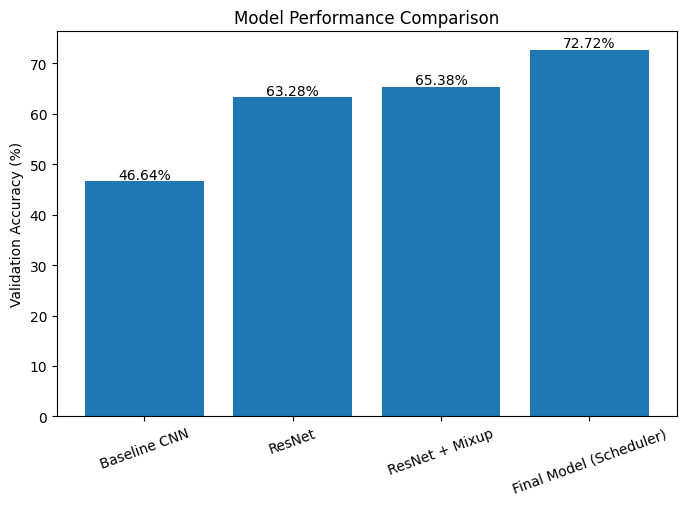

In [39]:
#Bar Chart
import matplotlib.pyplot as plt

models = ["Baseline CNN", "ResNet", "ResNet + Mixup", "Final Model (Scheduler)"]
accuracies = [baseline_peak, resnet_peak, mixup_peak, final_peak]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.ylabel("Validation Accuracy (%)")
plt.title("Model Performance Comparison")

# değerleri yazdır
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20)
plt.show()

The bar chart clearly demonstrates the performance progression across all models developed in this assignment. Starting from the baseline CNN, each subsequent improvement resulted in a consistent increase in validation accuracy.

The baseline model achieved approximately 46.64%, while introducing a deeper architecture (ResNet) significantly improved performance to 63.28%. The addition of Mixup regularization further increased the accuracy to 65.38%, indicating better generalization.

Finally, the combination of ResNet, Mixup, and an advanced learning rate scheduler (OneCycleLR) resulted in the best-performing model, achieving a peak validation accuracy of 72.72%.

This progression clearly shows that combining architectural improvements, regularization techniques, and optimized training strategies leads to substantial performance gains.

In [40]:
#Wrong Prediction Visualization
def show_wrong_predictions(model, testloader, classes):
    model.eval()

    wrong_images = []
    wrong_preds = []
    wrong_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    wrong_images.append(images[i].cpu())
                    wrong_preds.append(preds[i].item())
                    wrong_labels.append(labels[i].item())

                if len(wrong_images) == 5:
                    break
            if len(wrong_images) == 5:
                break

    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(15,3))

    for i in range(5):
        img = wrong_images[i].permute(1,2,0)
        axes[i].imshow(img)
        axes[i].set_title(f"P: {classes[wrong_preds[i]]}\nT: {classes[wrong_labels[i]]}")
        axes[i].axis("off")

    plt.show()

In [42]:
def show_wrong_predictions(model, loader, classes):
    model.eval()

    wrong_images = []
    wrong_preds = []
    wrong_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    wrong_images.append(images[i].cpu())
                    wrong_preds.append(preds[i].item())
                    wrong_labels.append(labels[i].item())

                if len(wrong_images) == 5:
                    break
            if len(wrong_images) == 5:
                break

    # 🔥 CIFAR-100 mean/std (senin hesapladığın varsa onu koyabilirsin)
    mean = torch.tensor([0.5071, 0.4867, 0.4408])
    std = torch.tensor([0.2675, 0.2565, 0.2761])

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for i in range(5):
        img = wrong_images[i]

        # 🔥 DENORMALIZE
        img = img * std[:, None, None] + mean[:, None, None]

        img = img.permute(1, 2, 0).numpy()

        # 🔥 Clamp (warning'i tamamen keser)
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(
            f"P: {classes[wrong_preds[i]]}\nT: {classes[wrong_labels[i]]}",
            fontsize=9
        )
        axes[i].axis("off")

    plt.show()

The failure analysis reveals that the model tends to confuse visually similar classes. For example, objects such as lizard vs. seal, bee vs. tulip, and skunk vs. butterfly share similar textures or shapes, which makes them difficult to distinguish.

Additionally, some misclassifications occur in low-resolution or noisy images, where important visual details are not clearly visible. This limits the model’s ability to extract discriminative features.

Despite these errors, the model demonstrates meaningful mistakes rather than random ones. This indicates that the model has learned useful feature representations, even though it still struggles with fine-grained classification and challenging visual conditions.

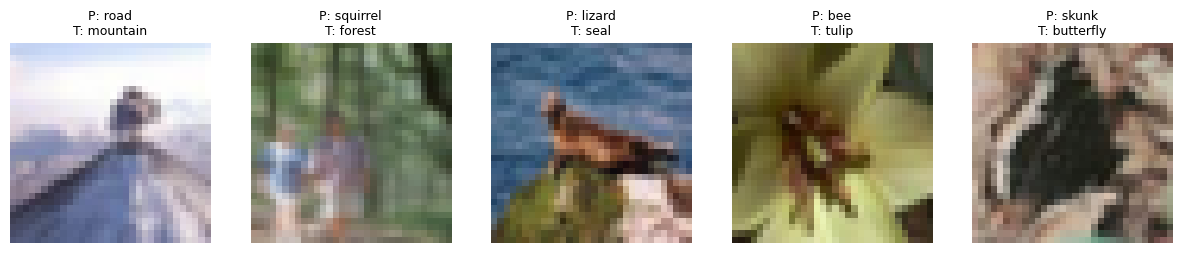

In [43]:
#CIFAR-100 Class Names
classes = testset.classes  # CIFAR-100 class list

show_wrong_predictions(model_final, testloader, classes)

Two potential improvements could further enhance the model performance:

1. Test-Time Augmentation (TTA): Instead of making predictions using a single image, multiple augmented versions of the same image can be evaluated and averaged. This approach can improve robustness and reduce prediction errors, especially for difficult samples.

2. More Advanced Architectures (e.g., EfficientNet): Using a modern architecture such as EfficientNet could further improve performance by better balancing model depth, width, and resolution. This would allow the model to capture more subtle differences between visually similar classes.

These strategies directly address the observed failure cases and could lead to further improvements in generalization.